# Random forest Climatology: Air temperature observations (UK)

In this notebook, we model temperature over the UK region using a random forest model.
We load observations data with additional predictors (roughness, land fraction), apply suitable transformations.

Data: 

observations_qc.csv

land_fraction_data.csv

roughness_data.csv

We use additional predictors along with the intially provided covariates to potentially improve learning process of our models.

Model and libraries:
We use scikit-learn to build random forest based climatology models and evaluate them with MAE metric.
Furthermore, we create various visual plots to analyse the results.


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import norm

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text
import matplotlib.patheffects as pe

# Libraries for Neural Networks
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import layers, models
import datetime
from tensorflow.keras.callbacks import TensorBoard
import keras
print(tf.__version__)

import keras_tuner
import math

#Random Forest Libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

2.19.0


## Loading Observations

In [3]:
obs = pd.read_csv('./datasets/observations_qc.csv', compression="gzip", parse_dates=["time"])
land_frac_data = pd.read_csv('./datasets/land_fraction_data.csv', compression="gzip")
roughness_data = pd.read_csv('./datasets/roughness_data.csv', compression="gzip")

obs = obs.merge(land_frac_data, how='left', on=['wmo_id','latitude','longitude', 'altitude'])
obs = obs.merge(roughness_data, how='left', on=['wmo_id','latitude','longitude', 'altitude'])

print(obs.shape)
print(obs.columns)
print((obs['ob_value']-273.15).min())
print((obs['ob_value']-273.15).max())

(9232630, 9)
Index(['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude',
       'altitude', 'land_fraction', 'roughness'],
      dtype='object')
-79.64999999999998
58.25


In [4]:
obs.head(10)

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness
0,255.0,2025-02-01 02:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
1,254.8,2025-02-01 04:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
2,255.3,2025-02-01 06:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
3,255.5,2025-02-01 07:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
4,255.3,2025-02-01 08:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
5,254.5,2025-02-01 09:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
6,254.5,2025-02-01 10:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
7,254.1,2025-02-01 12:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
8,253.6,2025-02-01 13:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
9,255.4,2025-02-01 19:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615


## UK Data Subset

In [6]:
obs_uk = obs[(obs['latitude'] > 49.8) & (obs['latitude'] < 61.5)  & (obs['longitude'] > -8.5) & (obs['longitude'] < 1.8)]
obs = obs_uk.copy()
obs_uk.shape[0]

708705

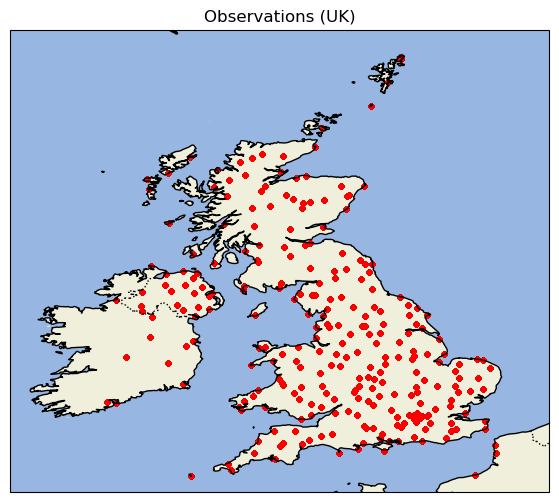

In [7]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
#ax.set_global()

# Plot points
ax.scatter(obs_uk['longitude'], obs_uk['latitude'], color='red', s=8, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Observations (UK)")
plt.show()


## Data Transformations

In [10]:
# Transforming date to a cyclic pattern in a 365 day cycle
obs['day_of_year'] = obs['time'].dt.dayofyear
obs['hour'] = pd.to_datetime(obs['time']).dt.hour

#obs['sin_day'] = np.sin(2 * np.pi * (obs['day_of_year'] + obs['hour']/24) / 365).round(5)
#obs['cos_day'] = np.cos(2 * np.pi * (obs['day_of_year'] + obs['hour']/24) / 365).round(5)

obs['sin_day'] = np.sin(2 * np.pi * obs['day_of_year'] / 365).round(5)
obs['cos_day'] = np.cos(2 * np.pi * obs['day_of_year'] / 365).round(5)

# Transforming time to a cyclic pattern - 24 hour cycle by calculating the solar time at positions
obs['sin_hour'] = np.sin(2 * np.pi * (obs['hour'] + 24 * (obs['longitude'] / 360)) / 24).round(5)
obs['cos_hour'] = np.cos(2 * np.pi * (obs['hour'] + 24 * (obs['longitude'] / 360)) / 24).round(5)


In [11]:
# Transforming latitude, longitude to [-1,1] range
#obs['lat'] = (obs['latitude']/90.0).round(5)
obs['sin_lat'] = np.sin(np.radians(obs['latitude'])).round(5)
obs['cos_lat'] = np.cos(np.radians(obs['latitude'])).round(5)
obs['sin_long'] = np.sin(np.radians(obs['longitude'])).round(5)
obs['cos_long'] = np.cos(np.radians(obs['longitude'])).round(5)

obs['temp_celcius'] = obs['ob_value'] - 273.15

In [12]:
obs.head(10)

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness,day_of_year,hour,sin_day,cos_day,sin_hour,cos_hour,sin_lat,cos_lat,sin_long,cos_long,temp_celcius
3824615,281.1,2025-02-01 00:00:00+00:00,3803,temperature_at_screen_level,49.914,-6.296,36.0,0.0000,0.03,32,0,0.52342,0.85208,-0.10966,0.99397,0.76508,0.64394,-0.10966,0.99397,7.95
3824616,281.1,2025-02-01 01:00:00+00:00,3803,temperature_at_screen_level,49.914,-6.296,36.0,0.0000,0.03,32,1,0.52342,0.85208,0.15133,0.98848,0.76508,0.64394,-0.10966,0.99397,7.95
3824617,281.1,2025-02-01 02:00:00+00:00,3803,temperature_at_screen_level,49.914,-6.296,36.0,0.0000,0.03,32,2,0.52342,0.85208,0.40201,0.91563,0.76508,0.64394,-0.10966,0.99397,7.95
3824618,281.4,2025-02-01 03:00:00+00:00,3803,temperature_at_screen_level,49.914,-6.296,36.0,0.0000,0.03,32,3,0.52342,0.85208,0.62530,0.78039,0.76508,0.64394,-0.10966,0.99397,8.25
3824619,281.2,2025-02-01 04:00:00+00:00,3803,temperature_at_screen_level,49.914,-6.296,36.0,0.0000,0.03,32,4,0.52342,0.85208,0.80597,0.59196,0.76508,0.64394,-0.10966,0.99397,8.05
3824620,282.0,2025-02-01 05:00:00+00:00,3803,temperature_at_screen_level,49.914,-6.296,36.0,0.0000,0.03,32,5,0.52342,0.85208,0.93172,0.36319,0.76508,0.64394,-0.10966,0.99397,8.85
3824633,276.4,2025-02-01 00:00:00+00:00,7040,temperature_at_screen_level,49.932,1.089,38.0,0.1581,0.03,32,0,0.52342,0.85208,0.01901,0.99982,0.76528,0.64370,0.01901,0.99982,3.25
3824634,276.4,2025-02-01 01:00:00+00:00,7040,temperature_at_screen_level,49.932,1.089,38.0,0.1581,0.03,32,1,0.52342,0.85208,0.27713,0.96083,0.76528,0.64370,0.01901,0.99982,3.25
3824635,276.0,2025-02-01 02:00:00+00:00,7040,temperature_at_screen_level,49.932,1.089,38.0,0.1581,0.03,32,2,0.52342,0.85208,0.51637,0.85637,0.76528,0.64370,0.01901,0.99982,2.85
3824636,275.8,2025-02-01 03:00:00+00:00,7040,temperature_at_screen_level,49.932,1.089,38.0,0.1581,0.03,32,3,0.52342,0.85208,0.72042,0.69354,0.76528,0.64370,0.01901,0.99982,2.65


## Random Forest Regressor using Scikit-Learn 

### Data Preparation

In [15]:
df = obs.copy()
df.columns

Index(['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude',
       'altitude', 'land_fraction', 'roughness', 'day_of_year', 'hour',
       'sin_day', 'cos_day', 'sin_hour', 'cos_hour', 'sin_lat', 'cos_lat',
       'sin_long', 'cos_long', 'temp_celcius'],
      dtype='object')

In [16]:
#Splitting dataset into train, test and validation set with a ratio of 70:15:15.
unique_wmo_ids = df['wmo_id'].unique()
unique_wmo_ids.shape
np.random.seed(0)
np.random.shuffle(unique_wmo_ids)

#Splitting data by 70-30 ratio
split_index = int(0.7 * len(unique_wmo_ids))
train_ids = unique_wmo_ids[:split_index]

split_index_1 = int(0.5 * (len(unique_wmo_ids) - len(train_ids)))
val_ids = unique_wmo_ids[split_index : (split_index + split_index_1)]
test_ids = unique_wmo_ids[(split_index + split_index_1):]

df_train = df[df['wmo_id'].isin(train_ids)]
df_val = df[df['wmo_id'].isin(val_ids)]
df_test = df[df['wmo_id'].isin(test_ids)]

print(train_ids.shape)
print(val_ids.shape)
print(test_ids.shape)
print(df_train.shape)
print(df_val.shape)
print(df_test.shape)


(191,)
(41,)
(41,)
(496810, 20)
(108568, 20)
(103327, 20)


### Visualising train, test sites and storing data for visualisations

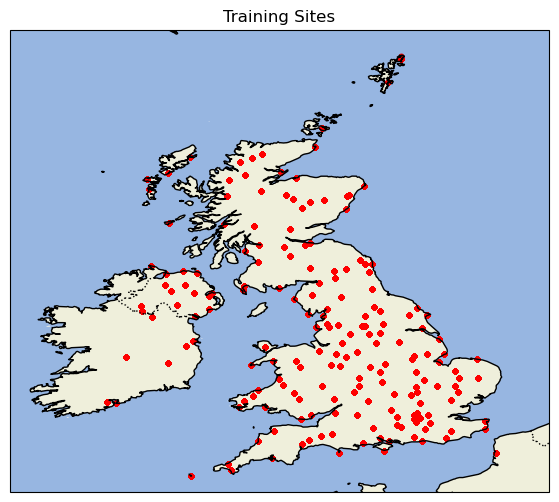

In [18]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
#ax.set_global()

# Plot points
ax.scatter(df_train['longitude'], df_train['latitude'], color='red', s=10, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Training Sites")
plt.show()

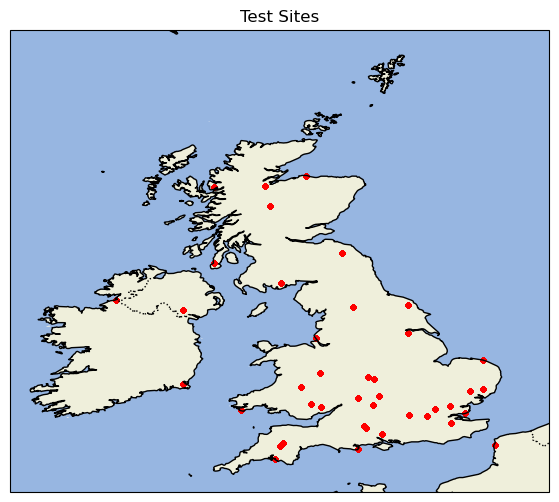

In [19]:
# Create a map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
#ax.set_global()

# Plot points
ax.scatter(df_test['longitude'], df_test['latitude'], color='red', s=10, alpha=0.7, transform=ccrs.PlateCarree())

plt.title("Test Sites")
plt.show()

In [20]:
map_values = df_test[['latitude', 'longitude','altitude', 'temp_celcius', 'day_of_year', 'hour']]
map_values

,latitude,longitude,altitude,temp_celcius,day_of_year,hour
6030894,51.555,0.827,2.0,4.05,32,0
6030895,51.555,0.827,2.0,4.65,32,1
6030896,51.555,0.827,2.0,4.55,32,2
6030897,51.555,0.827,2.0,4.45,32,3
6030898,51.555,0.827,2.0,4.45,32,4
...,...,...,...,...,...,...
8147103,57.418,-5.689,773.0,11.05,140,7
8147104,57.418,-5.689,773.0,12.35,140,8
8147105,57.418,-5.689,773.0,10.95,140,9
8147106,57.418,-5.689,773.0,10.35,140,10


### Training Data

In [25]:
df_train = df_train.drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])
df_val = df_val.drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])
df_test = df_test.drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])

df_test

,altitude,land_fraction,roughness,sin_day,cos_day,sin_hour,cos_hour,sin_lat,cos_lat,sin_long,cos_long,temp_celcius
6030894,2.0,0.988718,0.03,0.52342,0.85208,0.01443,0.99990,0.78321,0.62176,0.01443,0.99990,4.05
6030895,2.0,0.988718,0.03,0.52342,0.85208,0.27273,0.96209,0.78321,0.62176,0.01443,0.99990,4.65
6030896,2.0,0.988718,0.03,0.52342,0.85208,0.51245,0.85872,0.78321,0.62176,0.01443,0.99990,4.55
6030897,2.0,0.988718,0.03,0.52342,0.85208,0.71724,0.69683,0.78321,0.62176,0.01443,0.99990,4.45
6030898,2.0,0.988718,0.03,0.52342,0.85208,0.87315,0.48745,0.78321,0.62176,0.01443,0.99990,4.45
...,...,...,...,...,...,...,...,...,...,...,...,...
8147103,773.0,0.970741,0.03,0.66806,-0.74410,0.98682,-0.16179,0.84262,0.53851,-0.09913,0.99507,11.05
8147104,773.0,0.970741,0.03,0.66806,-0.74410,0.91132,-0.41169,0.84262,0.53851,-0.09913,0.99507,12.35
8147105,773.0,0.970741,0.03,0.66806,-0.74410,0.77372,-0.63353,0.84262,0.53851,-0.09913,0.99507,10.95
8147106,773.0,0.970741,0.03,0.66806,-0.74410,0.58339,-0.81220,0.84262,0.53851,-0.09913,0.99507,10.35


In [26]:
X_train = df_train.iloc[:, :11].values
y_train = df_train.iloc[:, 11].values
X_val = df_val.iloc[:, :11].values
y_val = df_val.iloc[:, 11].values
X_test = df_test.iloc[:, :11].values
y_test = df_test.iloc[:, 11].values

y_test.max()

27.650000000000034

In [34]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train.shape

(496810, 11)

### Fitting a Random Forest

In [56]:
# Create and train a Random Forest Regression model
model = RandomForestRegressor(n_estimators=300, random_state=42, 
                                     criterion='squared_error', max_depth=50,
                                     min_samples_split=2, min_samples_leaf=1, bootstrap=True, warm_start=True, n_jobs=-1)
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,50
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Fitting multiple models (optional)

The below cell defines a method that fits multiple models with different number of trees and compares their performance. This is optional to execute. Fitting a single model with fixed number of trees is quick to run.

In [59]:
train_losses = []
val_losses = []
# defining a range of n_estimators, to obtain a best value
n_estimators_range = range(500, 670, 40)

In [61]:
for n in n_estimators_range:
    model.set_params(n_estimators=n)
    model.fit(X_train, y_train)

    # Predict on both train and val
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_loss = mean_squared_error(y_train, y_train_pred)
    val_loss = mean_squared_error(y_val, y_val_pred)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"{n} trees: Train MSE = {train_loss:.4f}, Val MSE = {val_loss:.4f}")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:465: UserWarning: Warm-start fitting without increasing n_estimators does not fit new trees.
  warn(


500 trees: Train MSE = 2.3777, Val MSE = 3.0320
540 trees: Train MSE = 2.3765, Val MSE = 3.0311
580 trees: Train MSE = 2.3755, Val MSE = 3.0296
620 trees: Train MSE = 2.3759, Val MSE = 3.0308
660 trees: Train MSE = 2.3747, Val MSE = 3.0302


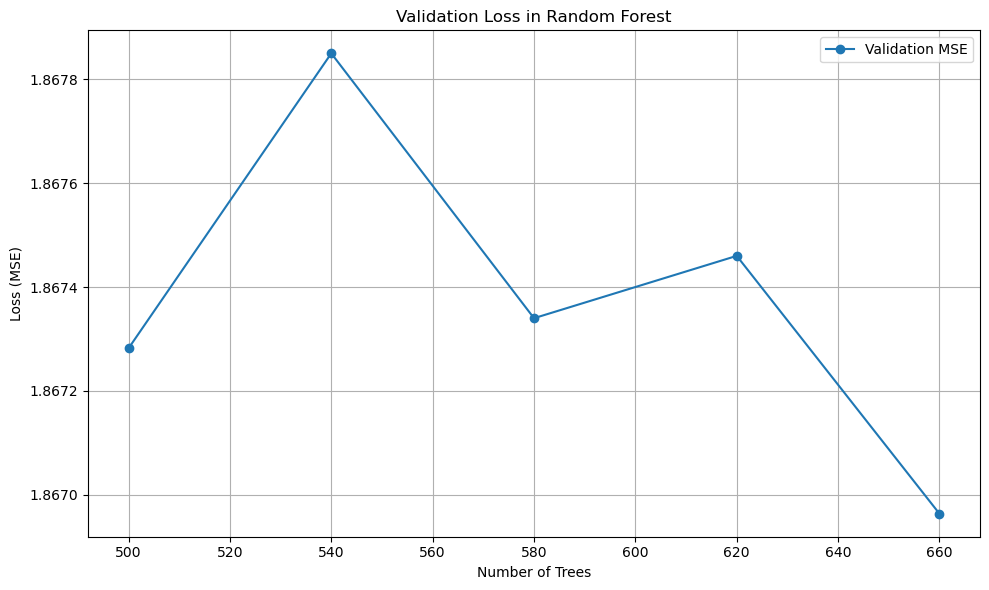

In [75]:
plt.figure(figsize=(10, 6))
#plt.plot(n_estimators_range, train_losses, label="Train MSE", marker='o')
plt.plot(n_estimators_range, val_losses, label="Validation MSE", marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Loss (MSE)")
plt.title("Validation Loss in Random Forest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Save model

In [ ]:
##save
#joblib.dump(model, "./saved_models/RF_model_uk_v2.joblib")

In [67]:
## load
#model = joblib.load("./saved_models/RF_model_uk_v2.joblib")

In [115]:
train_errors, val_errors = [], []
train_errors.append(mean_squared_error(y_train, model.predict(X_train)))
val_errors.append(mean_squared_error(y_val, model.predict(X_val)))

### Evaluate 

In [58]:
# Make predictions on the test data
preds = model.predict(X_test)
r2score = model.score(X_test, y_test)
print(f'R2 Score: {r2score : .3f}')
# Evaluate the model by calculating Mean Squared Error (MSE)
mse = mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

R2 Score:  0.924
Mean Squared Error: 1.830065446995138
Mean Absolute Error: 0.9552785783644804


In [54]:
# Average depth of each tree
depths = [estimator.tree_.max_depth for estimator in model.estimators_]
print("Average depth:", np.mean(depths))


Average depth: 40.93666666666667


### Visualisation of results

In [60]:
## creating a dataframe to store visualise outputs and plot against predictors

tempdf = pd.DataFrame({
    'latitude' : map_values['latitude'],
    'longitude' : map_values['longitude'],
    'altitude' : map_values['altitude'],
    'day_of_year' : map_values['day_of_year'],
    'y_test' : y_test,
    'predicted' : preds.reshape(-1),
    'error' : y_test-preds.reshape(-1)
})
tempdf

,latitude,longitude,altitude,day_of_year,y_test,predicted,error
6030894,51.555,0.827,2.0,32,4.2,4.634333,-0.434333
6030895,51.555,0.827,2.0,32,4.8,4.475667,0.324333
6030896,51.555,0.827,2.0,32,4.7,4.287667,0.412333
6030897,51.555,0.827,2.0,32,4.6,4.077333,0.522667
6030898,51.555,0.827,2.0,32,4.6,3.484667,1.115333
...,...,...,...,...,...,...,...
8147103,57.418,-5.689,773.0,140,11.2,10.462667,0.737333
8147104,57.418,-5.689,773.0,140,12.5,10.932333,1.567667
8147105,57.418,-5.689,773.0,140,11.1,13.015333,-1.915333
8147106,57.418,-5.689,773.0,140,10.5,14.358667,-3.858667


In [ ]:
tempdf_grouped = tempdf.groupby(['y_test'], as_index = False).agg({
    'predicted' : ['mean', 'std']
})

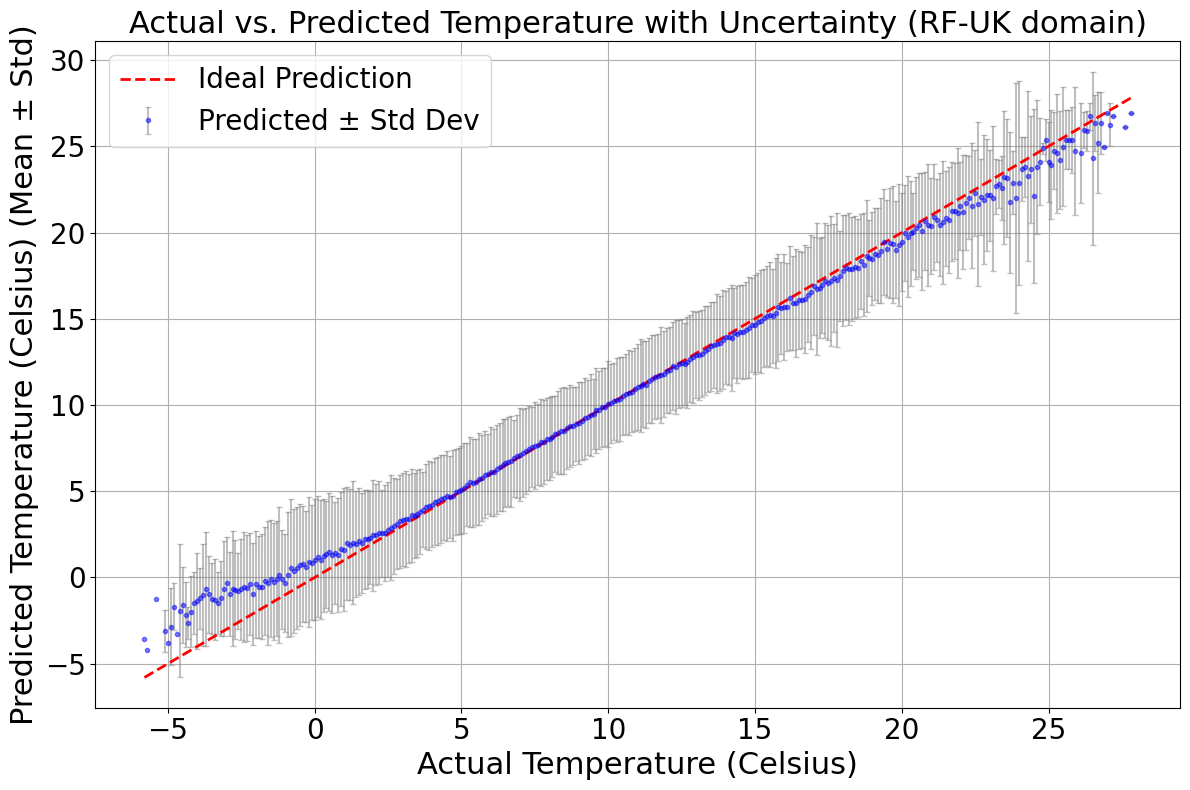

In [68]:
# Actual vs. Predicted Temperature with Uncertainty (RF-UK domain)

errors = abs(tempdf_grouped['predicted']['mean'] - tempdf_grouped['y_test'])
errors = errors.astype(int)

plt.figure(figsize=(12, 8))
plt.errorbar(tempdf_grouped['y_test'], tempdf_grouped['predicted']['mean'], yerr=2*tempdf_grouped['predicted']['std'], fmt='o', alpha=0.5, markersize=3,
             ecolor='gray', capsize=2, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Ideal Prediction', linewidth=2)

plt.xlabel('Actual Temperature (Celsius)', fontsize=22)
plt.ylabel('Predicted Temperature (Celsius) (Mean ± Std)', fontsize=22)
plt.title('Actual vs. Predicted Temperature with Uncertainty (RF-UK domain)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/pw/b7xk2wbj2zlghgd_7c0zcfp40000gn/T/ipykernel_33413/1159193220.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()


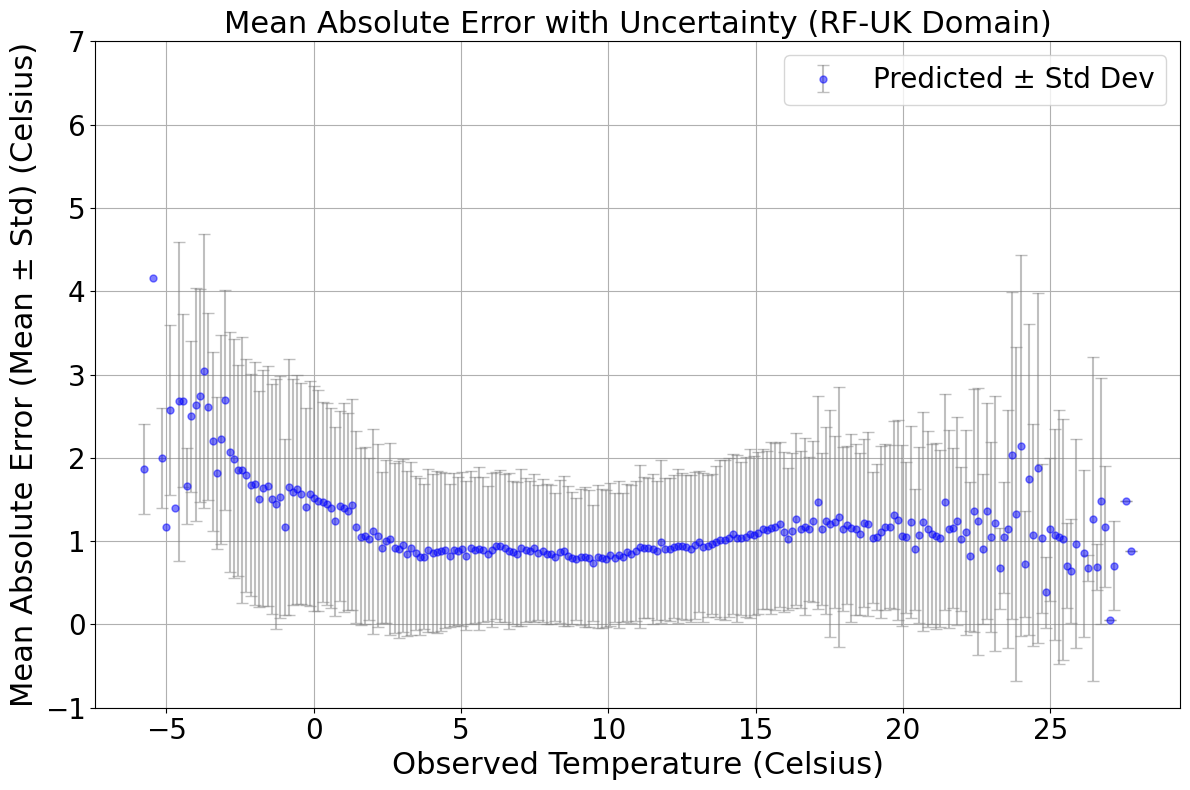

In [70]:
## Mean of MAE within temperature bins. the temperature range has been divided into 234 bins.

temp_bins = pd.cut(tempdf['y_test'], bins=234)
tempdf1 = tempdf.copy()
tempdf1['error'] = np.abs(tempdf1['error'])
temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()
temp_bin_error['temp_center'] = temp_bin_error['y_test'].apply(lambda x : x.mid)
temp_bin_error

plt.figure(figsize=(12, 8))
plt.errorbar(temp_bin_error['temp_center'], temp_bin_error['mean'], yerr=temp_bin_error['std'], fmt='o', alpha=0.5, markersize=5,
             ecolor='gray', capsize=4, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
#plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Perfect Prediction')

plt.ylim(-1,7)
#plt.ylim(-1,9)
plt.xlabel('Observed Temperature (Celsius)', fontsize=22)
plt.ylabel('Mean Absolute Error (Mean ± Std) (Celsius)', fontsize=22)
plt.title('Mean Absolute Error with Uncertainty (RF-UK Domain)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/pw/b7xk2wbj2zlghgd_7c0zcfp40000gn/T/ipykernel_33413/3470759332.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()


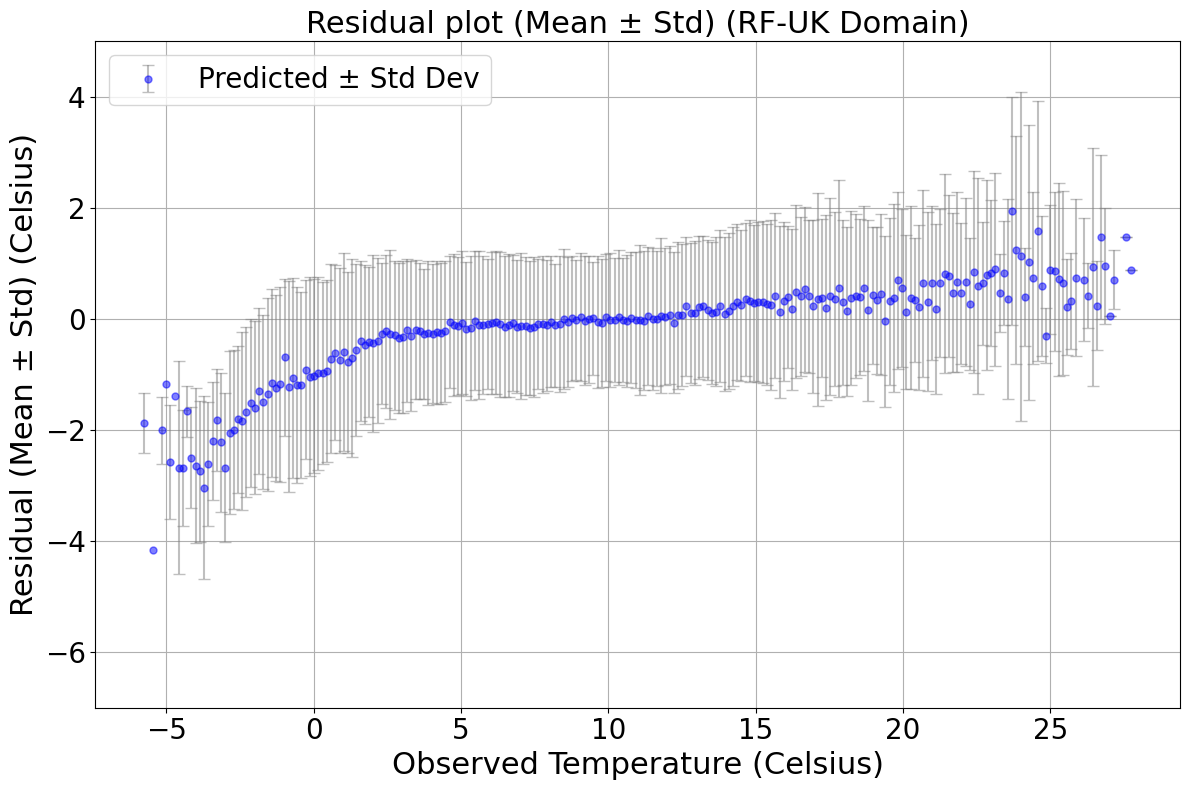

In [72]:
## Mean of residuals within temperature bins. the temperature range has been divided into 234 bins.

temp_bins = pd.cut(tempdf['y_test'], bins=234)
tempdf1 = tempdf.copy()
tempdf1['error'] = tempdf1['error']
temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()
temp_bin_error['temp_center'] = temp_bin_error['y_test'].apply(lambda x : x.mid)
temp_bin_error

plt.figure(figsize=(12, 8))
plt.errorbar(temp_bin_error['temp_center'], temp_bin_error['mean'], yerr=temp_bin_error['std'], fmt='o', alpha=0.5, markersize=5,
             ecolor='gray', capsize=4, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
#plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Perfect Prediction')

#plt.ylim(-2,19)
plt.ylim(-7,5)
plt.xlabel('Observed Temperature (Celsius)', fontsize=22)
plt.ylabel('Residual (Mean ± Std) (Celsius)', fontsize=22)
plt.title('Residual plot (Mean ± Std) (RF-UK Domain)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


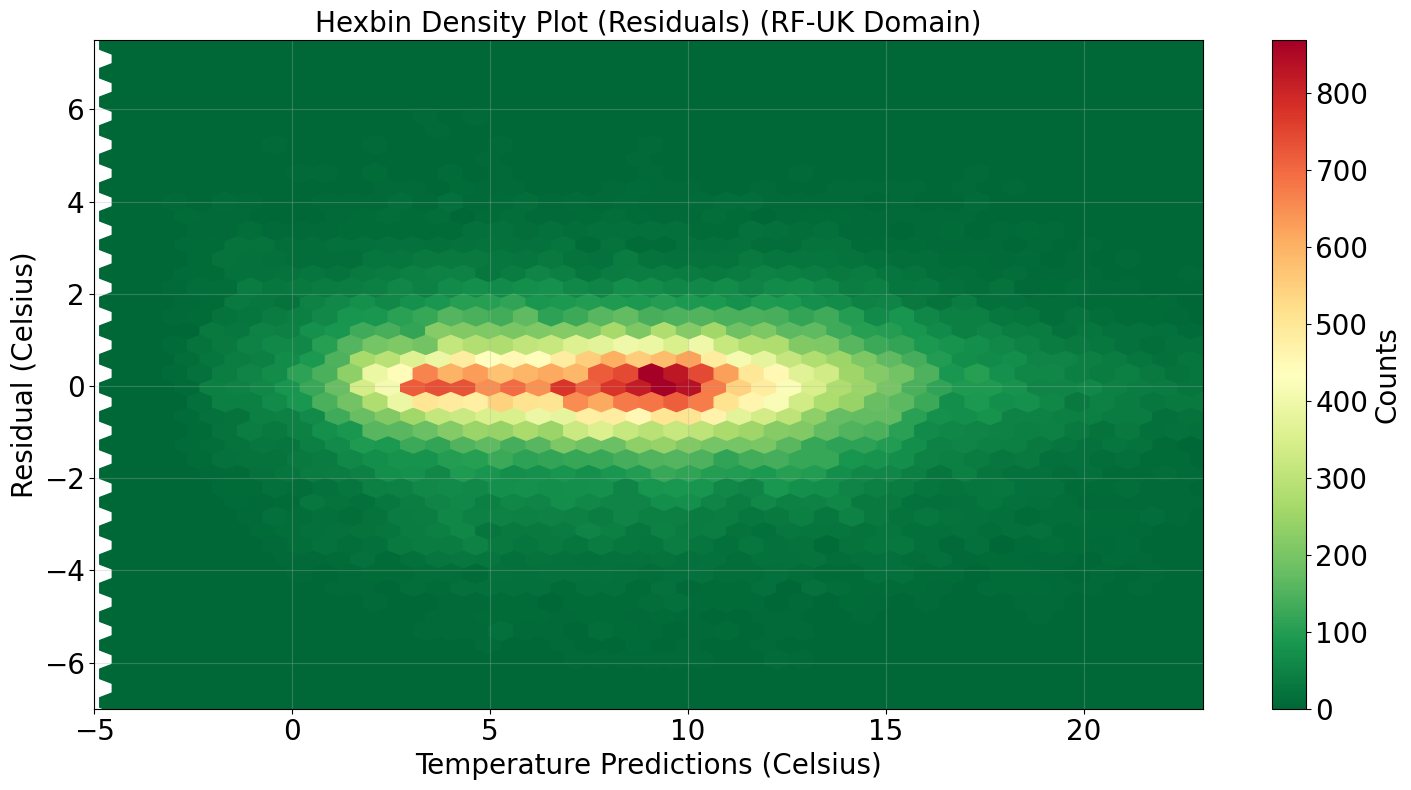

In [74]:
# Residual density plot

colors = ["green", "yellow", "red"]
custom_cmap = LinearSegmentedColormap.from_list("green_red", colors)

fig, ax = plt.subplots(figsize=(15, 8))

hb = ax.hexbin(
    tempdf['predicted'],
    tempdf['y_test'] - tempdf['predicted'],
    gridsize=50,
    cmap='RdYlGn_r'  # or custom_cmap
)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Counts', fontsize=20)   # colorbar label
cbar.ax.tick_params(labelsize=20)       # colorbar tick labels

ax.set_xlabel('Temperature Predictions (Celsius)', fontsize=20)
ax.set_ylabel('Residual (Celsius)', fontsize=20)
ax.set_title('Hexbin Density Plot (Residuals) (RF-UK Domain)', fontsize=20)

ax.set_ylim(-7, 7.5)
ax.set_xlim(-5, 23)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', which='both', labelsize=20)  # x/y tick labels

fig.tight_layout()
plt.show()


Text(0.5, 1.0, 'Actual vs Predicted Temperature (Test Set)')

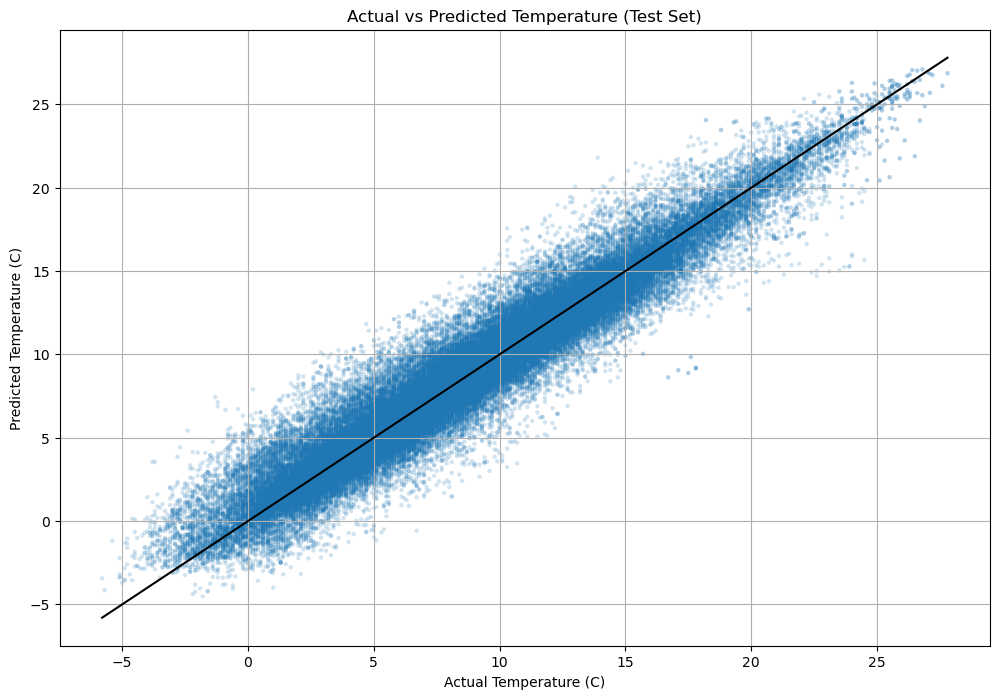

In [78]:
## Actual vs. Predicted Temperature

plt.figure(figsize=(12, 8))
plt.scatter(y_test, preds, s=10, alpha=0.2, edgecolors='none')
x_ = np.linspace(y_test.min(), y_test.max(), 100)
y_ = x_
plt.plot(x_, y_, color = 'black')
plt.grid(True)
#plt.xlim(-70,-35)
#plt.ylim(-80,-5)
plt.xlabel('Actual Temperature (C)')
plt.ylabel('Predicted Temperature (C)')
plt.title('Actual vs Predicted Temperature (Test Set)')

Text(0.5, 1.0, 'Residual Plot')

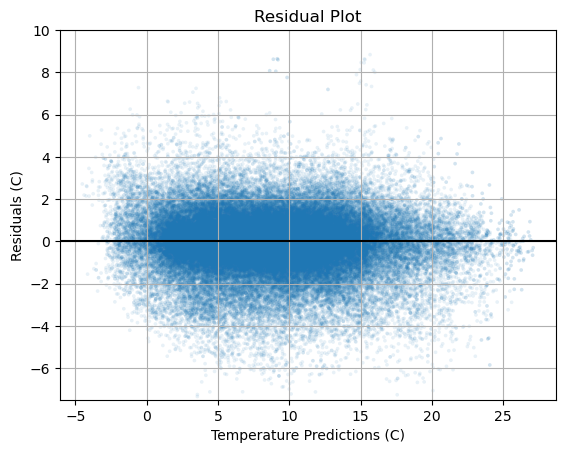

In [84]:
## Residual density plot

resids = tempdf['y_test'] - tempdf['predicted'] 
plt.scatter(tempdf['predicted'], resids, s=7, alpha=0.1, edgecolors='none')
plt.axhline(y=0, color='black')
plt.grid(True)
plt.ylim(-7.5,10)
plt.xlabel('Temperature Predictions (C)')
plt.ylabel('Residuals (C)')
plt.title('Residual Plot')

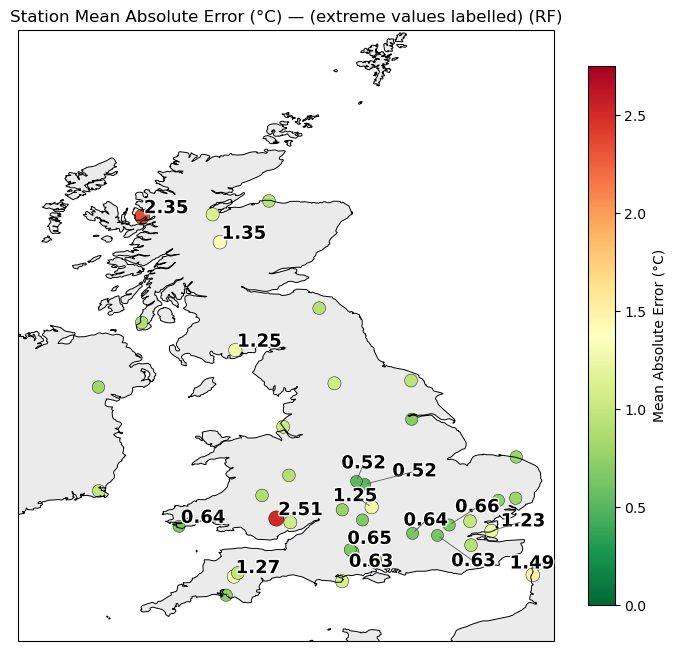

In [96]:
# MAE spatial distribution map

# df: columns ['station','lat','lon','mae']
fig = plt.figure(figsize=(7,8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-8, 2, 49.5, 60.9])
ax.add_feature(cfeature.LAND, facecolor='0.92'); ax.coastlines('10m', linewidth=0.7)

sizes = 30 + 90*np.sqrt(unique_test_locs['error']/unique_test_locs['error'].max())
sc = ax.scatter(unique_test_locs['longitude'], unique_test_locs['latitude'], c=unique_test_locs['error'], s=sizes, cmap='RdYlGn_r',
                edgecolor='k', linewidth=0.3, transform=ccrs.PlateCarree(), vmin=0, vmax=2.75)

# Label only extremes
idx = pd.concat([unique_test_locs.nlargest(8,'error'), unique_test_locs.nsmallest(8,'error')]).index.unique()
texts = []
for _, r in unique_test_locs.loc[idx].iterrows():
    t = ax.text(r['longitude'], r['latitude'], f"{r['error']:.2f}", transform=ccrs.PlateCarree(),
                fontsize=13, weight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    texts.append(t)

adjust_text(texts, expand_points=(1.2,1.6), force_points=0.5, force_text=0.5,
            arrowprops=dict(arrowstyle='-', color='0.35', lw=0.6))

cbar = plt.colorbar(sc, ax=ax, label="Mean Absolute Error (°C)", shrink=0.7,)
ax.set_title("Station Mean Absolute Error (°C) — (extreme values labelled) (RF)")
plt.tight_layout()